In [1]:
# Importing libraries
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the dataset
df_raw = pd.read_excel("7F_FRONT_SIDE_AHU_REPORT-26.xlsx", sheet_name="7F_FRONT_SIDE_AHU_REPORT0", header=None)

headers        = df_raw.iloc[3].tolist()
df_raw         = df_raw.iloc[4:].reset_index(drop=True)
df_raw.columns = [str(c).strip() for c in headers]

print(df_raw.shape)
print(df_raw.columns.tolist())
df_raw.head(3)

(4177, 8)
['DateTime', 'Run Status.', 'Return Air Temperature', 'Set Point.Present', 'Supply Air Temp.', 'CHW Valve Command. (%)', 'S Run Hours.', 'Frequency. (Hz)']


,DateTime,Run Status.,Return Air Temperature,Set Point.Present,Supply Air Temp.,CHW Valve Command. (%),S Run Hours.,Frequency. (Hz)
0,2026-04-01 00:00:00,5,25.539999,5,25.279999,0,86,0
1,2026-04-01 00:10:00,5,25.59,5,25.32,0,86,0
2,2026-04-01 00:20:00,5,25.609999,5,25.24,0,86,0


In [3]:
# df_raw = pd.read_excel("7F_FRONT_SIDE_AHU_REPORT-26.xlsx", sheet_name="7F_FRONT_SIDE_AHU_REPORT0", header=None)

# # Print first 6 rows raw to see exact structure
# for i in range(6):
#     print(f"Row {i}: {df_raw.iloc[i].tolist()}")

In [4]:
# Check column names
df_raw.columns.tolist()
# Check data types

['DateTime',
 'Run Status.',
 'Return Air Temperature',
 'Set Point.Present',
 'Supply Air Temp.',
 'CHW Valve Command. (%)',
 'S Run Hours.',
 'Frequency. (Hz)']

In [5]:
# Preview the dataset
df_raw.head()

,DateTime,Run Status.,Return Air Temperature,Set Point.Present,Supply Air Temp.,CHW Valve Command. (%),S Run Hours.,Frequency. (Hz)
0,2026-04-01 00:00:00,5,25.539999,5,25.279999,0,86,0
1,2026-04-01 00:10:00,5,25.59,5,25.32,0,86,0
2,2026-04-01 00:20:00,5,25.609999,5,25.24,0,86,0
3,2026-04-01 00:30:00,5,25.639999,5,25.189999,0,86,0
4,2026-04-01 00:40:00,5,24.769999,5,25.309999,0,86,0


In [6]:
# Define constants for column names and rolling window size
# Configure variables
TIMESTAMP_COL = "DateTime"
TARGET_COL    = "Return Air Temperature"
SETPOINT_COL  = "Set Point.Present"
CHW_COL       = "CHW Valve Command. (%)"
SUPPLY_COL    = "Supply Air Temp."
ROLLING_WIN   = 6

In [7]:
# Filter only Running rows
df_running = df_raw[df_raw["Run Status."] == "RUNNING"].reset_index(drop=True)

print("Total rows        :", len(df_raw))
print("Running rows only :", len(df_running))
df_running.head(3)

Total rows        : 4177
Running rows only : 2151


,DateTime,Run Status.,Return Air Temperature,Set Point.Present,Supply Air Temp.,CHW Valve Command. (%),S Run Hours.,Frequency. (Hz)
0,2026-04-01 05:20:00,RUNNING,25.82,5,25.639999,0,86,30.029999
1,2026-04-01 05:30:00,RUNNING,25.82,5,25.68,0,86,30.029999
2,2026-04-01 05:40:00,RUNNING,25.809999,5,25.689999,0,86,30.029999


In [8]:
# Clean and parse — only Running rows
df = df_running[[TIMESTAMP_COL, TARGET_COL, SETPOINT_COL, CHW_COL, SUPPLY_COL]].copy()

df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], format="mixed", errors="coerce")
df[TARGET_COL]    = pd.to_numeric(df[TARGET_COL], errors="coerce")
df[SETPOINT_COL]  = pd.to_numeric(df[SETPOINT_COL], errors="coerce")
df[CHW_COL]       = pd.to_numeric(df[CHW_COL],    errors="coerce")
df[SUPPLY_COL]    = pd.to_numeric(df[SUPPLY_COL], errors="coerce")

df = df.dropna().sort_values(TIMESTAMP_COL).reset_index(drop=True)

print("Clean rows :", len(df))
print("Date range :", df[TIMESTAMP_COL].min(), "→", df[TIMESTAMP_COL].max())

Clean rows : 2151
Date range : 2026-04-01 05:20:00 → 2026-04-30 00:00:00


In [9]:
# Summary stats
df.describe()

,DateTime,Return Air Temperature,Set Point.Present,CHW Valve Command. (%),Supply Air Temp.
count,2151,2151.000000,2151.000000,2151.000000,2151.000000
mean,2026-04-14 20:33:23.626220,23.226173,15.906555,53.056826,17.191283
min,2026-04-01 05:20:00,21.039999,0.000000,0.000000,10.660000
25%,2026-04-08 06:45:00,22.590000,5.000000,36.246599,14.775000
50%,2026-04-15 03:40:00,23.010000,23.000000,49.367413,16.330000
75%,2026-04-22 00:35:00,23.680000,23.000000,73.902184,18.835000
max,2026-04-30 00:00:00,29.240000,24.000000,100.000000,26.549999
std,NaN,1.037795,9.530617,29.481184,3.789631


In [10]:
# Remove rows where setpoint is 0, 3 and 5
df = df[~df[SETPOINT_COL].isin([0, 3, 5])].reset_index(drop=True)

print("Rows after removing setpoint 0, 3 and 5 :", len(df))
print("\nSetpoint values remaining:")
print(df[SETPOINT_COL].value_counts().sort_index())

Rows after removing setpoint 0, 3 and 5 : 1390

Setpoint values remaining:
Set Point.Present
21       1
22     219
23    1113
24      57
Name: count, dtype: int64


In [11]:
# Pearson correlation — all 3 factors vs Return Air Temperature
factors = {
    "Set Point"       : SETPOINT_COL,
    "CHW Valve (%)"   : CHW_COL,
    "Supply Air Temp" : SUPPLY_COL
}

print("=" * 55)
print(f"  TARGET: {TARGET_COL}")
print("=" * 55)

results = {}
for name, col in factors.items():
    r, p = stats.pearsonr(df[col], df[TARGET_COL])
    results[name] = {"r": r, "p": p, "R2": r**2}
    sig = "*** significant" if p < 0.001 else "* significant" if p < 0.05 else "not significant"
    print(f"\n  [{name}]")
    print(f"  Pearson r : {r:.4f}")
    print(f"  R²        : {r**2:.4f}  ({100*r**2:.1f}% variance explained)")
    print(f"  p-value   : {p:.2e}  {sig}")

  TARGET: Return Air Temperature

  [Set Point]
  Pearson r : 0.3185
  R²        : 0.1014  (10.1% variance explained)
  p-value   : 3.85e-34  *** significant

  [CHW Valve (%)]
  Pearson r : 0.1288
  R²        : 0.0166  (1.7% variance explained)
  p-value   : 1.46e-06  *** significant

  [Supply Air Temp]
  Pearson r : 0.7686
  R²        : 0.5907  (59.1% variance explained)
  p-value   : 1.49e-271  *** significant


In [12]:
# ── BASIC CALCULATIONS ────────────────────────────────────────

# 1. Temperature gap — Return Air vs Setpoint
df["gap_return_setpoint"] = df[TARGET_COL] - df[SETPOINT_COL]

# 2. Delta T — Return Air vs Supply Air
df["delta_T_return_supply"] = df[TARGET_COL] - df[SUPPLY_COL]

print("=== CALCULATED COLUMNS ===")
print(df[["DateTime", TARGET_COL, SETPOINT_COL, SUPPLY_COL,
          "gap_return_setpoint", "delta_T_return_supply"]].head(10).to_string())

=== CALCULATED COLUMNS ===
             DateTime  Return Air Temperature  Set Point.Present  Supply Air Temp.  gap_return_setpoint  delta_T_return_supply
0 2026-04-07 21:20:00               22.750000                 24         14.200000            -1.250000               8.550000
1 2026-04-07 21:30:00               22.799999                 24         14.730000            -1.200001               8.070000
2 2026-04-07 21:40:00               22.939999                 24         15.280000            -1.060001               7.659999
3 2026-04-07 21:50:00               23.029999                 24         15.790000            -0.970001               7.239999
4 2026-04-07 22:00:00               23.209999                 24         16.549999            -0.790001               6.660000
5 2026-04-07 22:10:00               23.359999                 24         17.160000            -0.640001               6.199999
6 2026-04-07 22:20:00               23.580000                 24         17.770000  

In [16]:
# ── SUMMARY STATS ON CALCULATED COLUMNS ──────────────────────

print("=== GAP: Return Air vs Setpoint ===")
print(f"  Mean   : {df['gap_return_setpoint'].mean():.4f} °C")
print(f"  Std    : {df['gap_return_setpoint'].std():.4f} °C")
print(f"  Min    : {df['gap_return_setpoint'].min():.4f} °C")
print(f"  Max    : {df['gap_return_setpoint'].max():.4f} °C")
print(f"  +ve    : {(df['gap_return_setpoint'] > 0).sum()} rows (above setpoint)")
print(f"  -ve    : {(df['gap_return_setpoint'] < 0).sum()} rows (below setpoint)")

print("\n=== DELTA T: Return Air vs Supply Air ===")
print(f"  Mean   : {df['delta_T_return_supply'].mean():.4f} °C")
print(f"  Std    : {df['delta_T_return_supply'].std():.4f} °C")
print(f"  Min    : {df['delta_T_return_supply'].min():.4f} °C")
print(f"  Max    : {df['delta_T_return_supply'].max():.4f} °C")

=== GAP: Return Air vs Setpoint ===
  Mean   : 0.1480 °C
  Std    : 0.8004 °C
  Min    : -1.7700 °C
  Max    : 4.8400 °C
  +ve    : 724 rows (above setpoint)
  -ve    : 649 rows (below setpoint)

=== DELTA T: Return Air vs Supply Air ===
  Mean   : 6.2665 °C
  Std    : 2.5665 °C
  Min    : -0.0200 °C
  Max    : 12.0800 °C


In [17]:
# ── HOURLY AVERAGES ───────────────────────────────────────────

df["hour"] = df[TIMESTAMP_COL].dt.hour

hourly = df.groupby("hour").agg(
    Return_Air_Mean     = (TARGET_COL,              "mean"),
    Setpoint_Mean       = (SETPOINT_COL,            "mean"),
    Supply_Air_Mean     = (SUPPLY_COL,              "mean"),
    CHW_Valve_Mean      = (CHW_COL,                 "mean"),
    Gap_Mean            = ("gap_return_setpoint",   "mean"),
    Gap_Max             = ("gap_return_setpoint",   "max"),
    DeltaT_Mean         = ("delta_T_return_supply", "mean"),
    DeltaT_Max          = ("delta_T_return_supply", "max"),
).round(4)

print("=== HOURLY AVERAGES ===")
print(hourly.to_string())

=== HOURLY AVERAGES ===
      Return_Air_Mean  Setpoint_Mean  Supply_Air_Mean  CHW_Valve_Mean  Gap_Mean  Gap_Max  DeltaT_Mean  DeltaT_Max
hour                                                                                                             
0             22.8107        22.8060          15.8712         50.2634    0.0048     1.48       6.9396        9.86
1             22.9208        22.6515          17.0673         56.0532    0.2692     2.26       5.8535       10.04
2             23.0694        22.7273          17.6223         62.3423    0.3421     2.41       5.4471       10.56
3             22.8765        22.6667          17.1761         64.4012    0.2098     3.10       5.7005       10.32
4             22.7787        22.8000          17.9211         61.6646   -0.0213     1.36       4.8576       10.61
5             23.7150        22.8750          23.0275         25.0000    0.8400     1.92       0.6875        0.96
6             23.9713        23.2000          23.5467         11

In [18]:
# ── DAILY AVERAGES ────────────────────────────────────────────

df["date"] = df[TIMESTAMP_COL].dt.date

daily = df.groupby("date").agg(
    Return_Air_Mean     = (TARGET_COL,              "mean"),
    Setpoint_Mean       = (SETPOINT_COL,            "mean"),
    Supply_Air_Mean     = (SUPPLY_COL,              "mean"),
    CHW_Valve_Mean      = (CHW_COL,                 "mean"),
    Gap_Mean            = ("gap_return_setpoint",   "mean"),
    Gap_Max             = ("gap_return_setpoint",   "max"),
    DeltaT_Mean         = ("delta_T_return_supply", "mean"),
    DeltaT_Max          = ("delta_T_return_supply", "max"),
).round(4)

print("=== DAILY AVERAGES ===")
print(daily.to_string())

=== DAILY AVERAGES ===
            Return_Air_Mean  Setpoint_Mean  Supply_Air_Mean  CHW_Valve_Mean  Gap_Mean  Gap_Max  DeltaT_Mean  DeltaT_Max
date                                                                                                                   
2026-04-07          23.6625        24.0000          18.0400         19.2599   -0.3375     0.36       5.6225        8.55
2026-04-08          22.9425        22.9717          16.6008         62.2064   -0.0292     1.19       6.3417       10.80
2026-04-09          22.8119        22.5946          16.8064         42.8331    0.2173     2.01       6.0055       10.90
2026-04-10          22.8879        22.4318          18.3147         50.6730    0.4561     3.22       4.5732       11.44
2026-04-15          22.9257        22.7706          16.8289         59.6994    0.1550     2.41       6.0968       10.76
2026-04-16          23.1525        22.8288          17.4016         55.6151    0.3237     2.77       5.7509       10.61
2026-04-17       

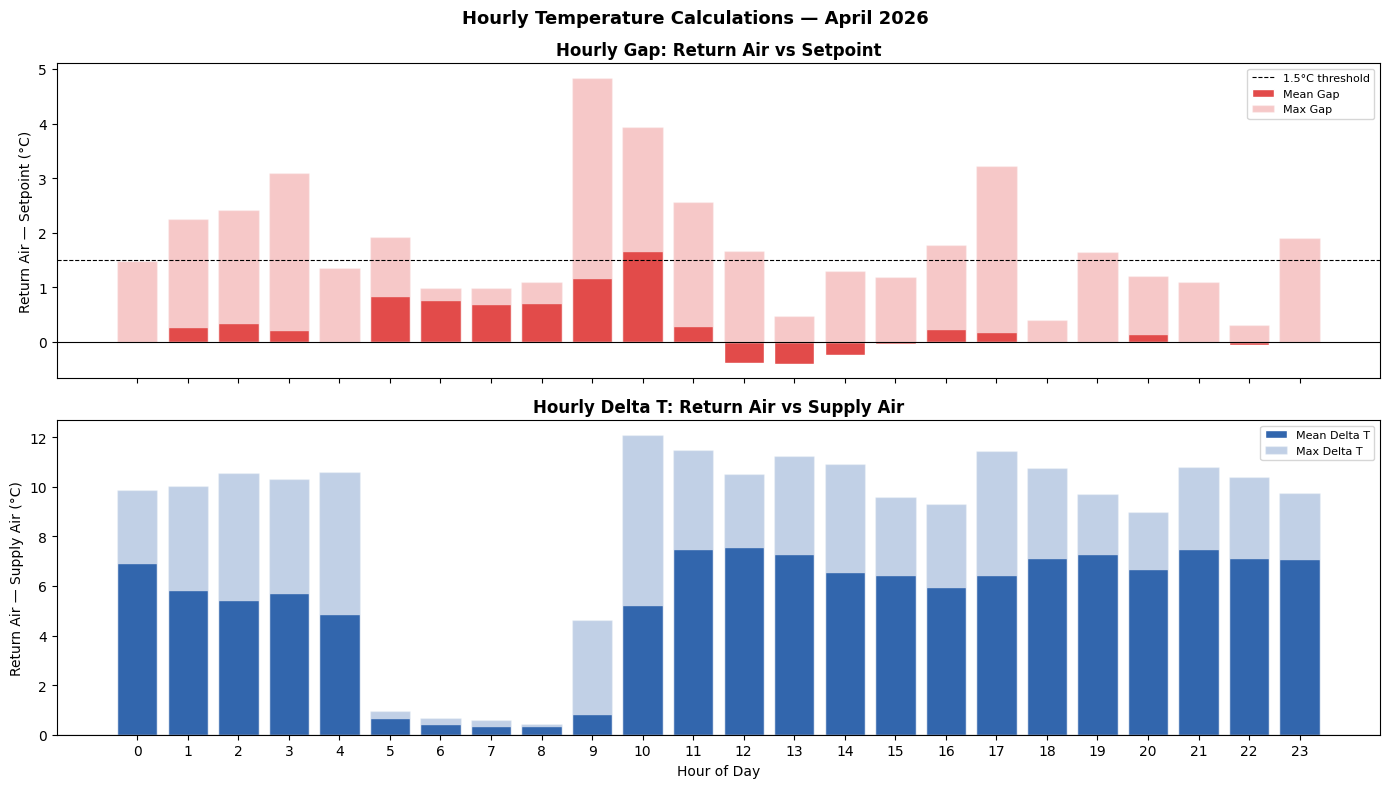

In [19]:
# ── PLOT 1 — Hourly averages of Gap and Delta T ───────────────

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.bar(hourly.index, hourly["Gap_Mean"], color="#e24b4a",
        edgecolor="white", label="Mean Gap")
ax1.bar(hourly.index, hourly["Gap_Max"], color="#e24b4a",
        edgecolor="white", alpha=0.3, label="Max Gap")
ax1.axhline(0, color="black", linewidth=0.8)
ax1.axhline(1.5, color="black", linewidth=0.8,
            linestyle="--", label="1.5°C threshold")
ax1.set_ylabel("Return Air — Setpoint (°C)")
ax1.set_title("Hourly Gap: Return Air vs Setpoint", fontweight="bold")
ax1.legend(fontsize=8)

ax2.bar(hourly.index, hourly["DeltaT_Mean"], color="#3266ad",
        edgecolor="white", label="Mean Delta T")
ax2.bar(hourly.index, hourly["DeltaT_Max"], color="#3266ad",
        edgecolor="white", alpha=0.3, label="Max Delta T")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Return Air — Supply Air (°C)")
ax2.set_title("Hourly Delta T: Return Air vs Supply Air", fontweight="bold")
ax2.set_xlabel("Hour of Day")
ax2.set_xticks(range(0, 24))
ax2.legend(fontsize=8)

plt.suptitle("Hourly Temperature Calculations — April 2026",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

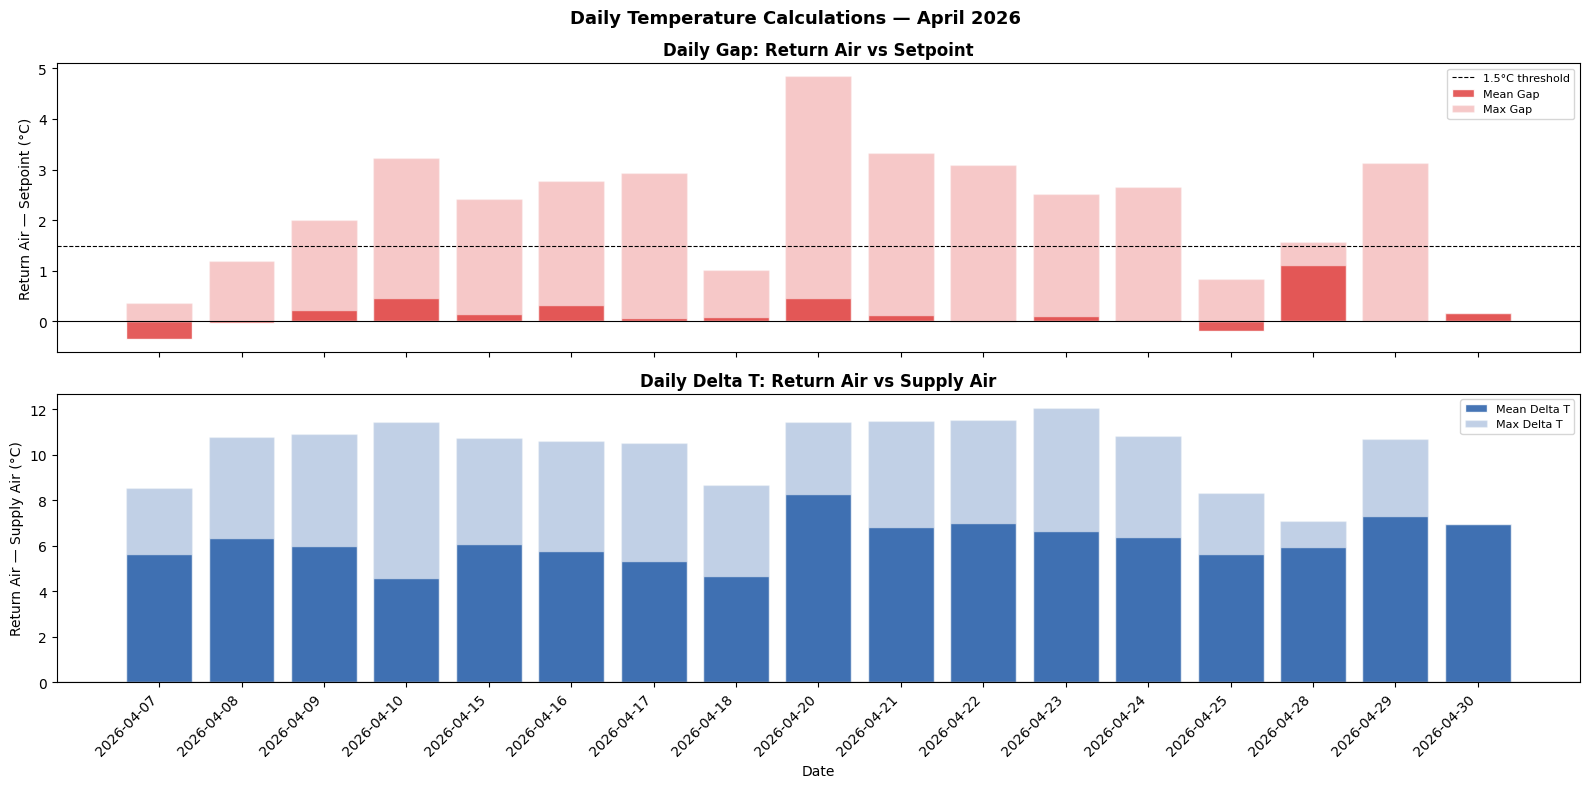

In [22]:
# ── PLOT 2 — Daily averages of Gap and Delta T ────────────────

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

x = range(len(daily))

ax1.bar(x, daily["Gap_Mean"],  color="#e24b4a", edgecolor="white",
        alpha=0.9, label="Mean Gap")
ax1.bar(x, daily["Gap_Max"],   color="#e24b4a", edgecolor="white",
        alpha=0.3, label="Max Gap")
ax1.axhline(0,   color="black", linewidth=0.8)
ax1.axhline(1.5, color="black", linewidth=0.8,
            linestyle="--", label="1.5°C threshold")
ax1.set_ylabel("Return Air — Setpoint (°C)")
ax1.set_title("Daily Gap: Return Air vs Setpoint", fontweight="bold")
ax1.legend(fontsize=8)

ax2.bar(x, daily["DeltaT_Mean"], color="#3266ad", edgecolor="white",
        alpha=0.9, label="Mean Delta T")
ax2.bar(x, daily["DeltaT_Max"],  color="#3266ad", edgecolor="white",
        alpha=0.3, label="Max Delta T")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Return Air — Supply Air (°C)")
ax2.set_title("Daily Delta T: Return Air vs Supply Air", fontweight="bold")
ax2.set_xlabel("Date")
ax2.set_xticks(x)
ax2.set_xticklabels([str(d) for d in daily.index], rotation=45, ha="right")
ax2.legend(fontsize=8)

plt.suptitle("Daily Temperature Calculations — April 2026",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

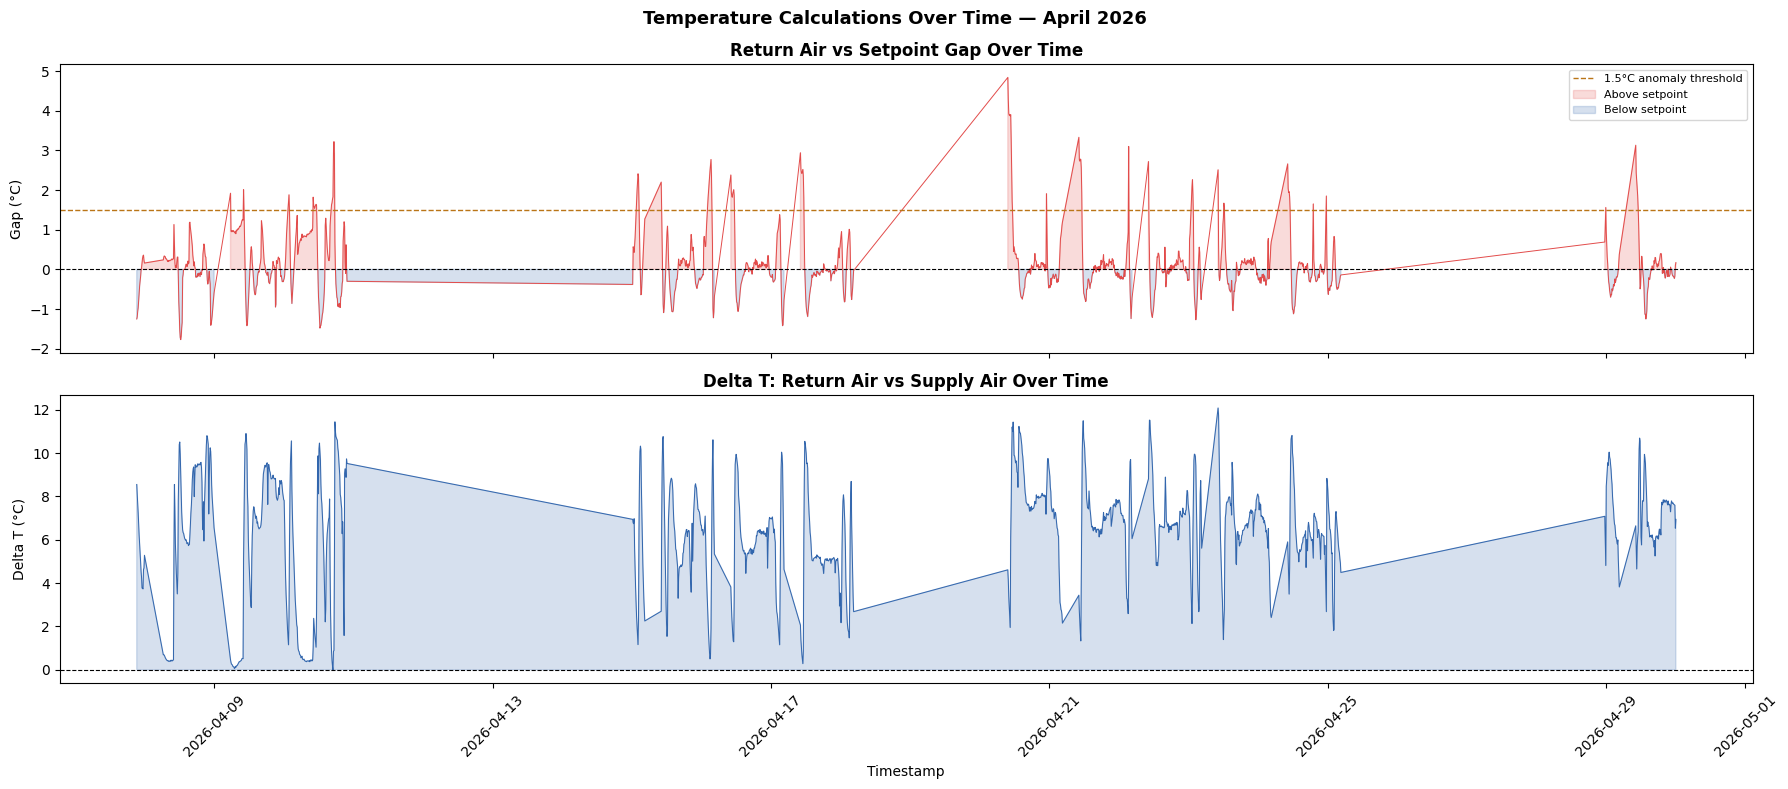

In [24]:
# ── PLOT 3 — Gap and Delta T over time (raw) ─────────────────

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

ax1.plot(df[TIMESTAMP_COL], df["gap_return_setpoint"],
         color="#e24b4a", linewidth=0.7)
ax1.axhline(0,   color="black",  linewidth=0.8, linestyle="--")
ax1.axhline(1.5, color="#ba7517", linewidth=1,  linestyle="--",
            label="1.5°C anomaly threshold")
ax1.fill_between(df[TIMESTAMP_COL], df["gap_return_setpoint"], 0,
                 where=df["gap_return_setpoint"] > 0,
                 alpha=0.2, color="#e24b4a", label="Above setpoint")
ax1.fill_between(df[TIMESTAMP_COL], df["gap_return_setpoint"], 0,
                 where=df["gap_return_setpoint"] < 0,
                 alpha=0.2, color="#3266ad", label="Below setpoint")
ax1.set_ylabel("Gap (°C)")
ax1.set_title("Return Air vs Setpoint Gap Over Time", fontweight="bold")
ax1.legend(fontsize=8)

ax2.plot(df[TIMESTAMP_COL], df["delta_T_return_supply"],
         color="#3266ad", linewidth=0.7)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.fill_between(df[TIMESTAMP_COL], df["delta_T_return_supply"], 0,
                 where=df["delta_T_return_supply"] > 0,
                 alpha=0.2, color="#3266ad")
ax2.set_ylabel("Delta T (°C)")
ax2.set_title("Delta T: Return Air vs Supply Air Over Time", fontweight="bold")
ax2.set_xlabel("Timestamp")

plt.suptitle("Temperature Calculations Over Time — April 2026",
             fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()